<img src="https://www.luxonis.com/logo.svg" width="400">

# Training an OCR Recognition Model

## 🌟 Overview
In this tutorial, we'll go through the process of training a custom OCR text recognition model. We'll first create a small synthetic OCR dataset, set up the training configuration, and then use it to train our own model. We'll also validate the performance, export it, and make it ready for deployment on a Luxonis device.

## 📜 Table of Contents
- [🛠️ Installation](#installation)
- [🗃️ Data Preparation](#data-preparation)
  - [🧐 Generating Synthetic Data](#generating-synthetic-data)
  - [💾 LuxonisDataset](#luxonisdataset)
- [🏋️‍♂️ Training](#training)
  - [⚙️ Configuration](#configuration)
  - [🦾 Train](#train)
- [✍ Test](#test)
  - [🧠 Infer](#infer)
- [🗂️ Export and Archive](#export-and-archive)
- [🤖 Deploy](#deploy)
- [📷 DepthAI Script](#depthai-script)


<a name="installation"></a>

## 🛠️ Installation


We'll use `LuxonisTrain` for training and `LuxonisML` for dataset handling. We'll also use `numpy`, `opencv-python`, and `Pillow` to generate a simple synthetic text-image dataset.


In [ ]:
%pip install -q luxonis-train==0.4.1 -U


<a name ="data-preparation"></a>

## 🗃️ Data Preparation


<a name ="generating-synthetic-data"></a>

### 🧐 Generating Synthetic Data


We'll synthesize images of alphanumeric strings using OpenCV. Each image will be 48px tall with variable width, containing a random 3-10 character string. We'll then wrap this into a `LuxonisDataset` suitable for OCR training.


In [ ]:
import os
import random
import string

import cv2
import numpy as np
from tqdm import tqdm

from luxonis_ml.data import LuxonisDataset, DatasetIterator, LuxonisLoader

ALPHANUM = string.ascii_letters + string.digits

def render_text_image(text: str, height: int = 48, pad: int = 4) -> np.ndarray:
    """Render a single-line text into an image with white text on black background."""
    font = cv2.FONT_HERSHEY_SIMPLEX
    scale = 0.8
    thickness = 2
    (w, h), _ = cv2.getTextSize(text, font, scale, thickness)
    img_w = max(32, w + pad * 2)
    img_h = max(height, h + pad * 2)
    img = np.zeros((img_h, img_w), dtype=np.uint8)
    baseline = (img_h + h) // 2 - 2
    x = (img_w - w) // 2
    cv2.putText(img, text, (x, baseline), font, scale, 255, thickness, lineType=cv2.LINE_AA)
    img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    return img

def generate_synthetic_split(out_dir: str, num_images: int, min_len: int = 3, max_len: int = 10) -> list[str]:
    os.makedirs(out_dir, exist_ok=True)
    paths: list[str] = []
    for i in tqdm(range(num_images)):
        length = random.randint(min_len, max_len)
        text = ''.join(random.choice(ALPHANUM) for _ in range(length))
        img = render_text_image(text)
        path = os.path.join(out_dir, f"{text}_{i}.png")
        cv2.imwrite(path, cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
        paths.append(path)
    return paths

def make_ocr_generator(image_paths: list[str]) -> DatasetIterator:
    labels = [os.path.basename(p).split('_')[0] for p in image_paths]
    def gen() -> DatasetIterator:
        for p, label in zip(image_paths, labels):
            yield {
                "file": os.path.abspath(p),
                "annotation": {
                    "metadata": {"text": label},
                },
            }
    return gen()

# Create synthetic dataset directories
train_paths = generate_synthetic_split("synthetic_ocr/train", 800)
val_paths = generate_synthetic_split("synthetic_ocr/val", 100)
test_paths = generate_synthetic_split("synthetic_ocr/test", 100)

# Create LuxonisDataset and add splits
ocr_dataset_name = "synthetic_ocr_dataset"
if LuxonisDataset.exists(ocr_dataset_name):
    dataset = LuxonisDataset(ocr_dataset_name, delete_local=True)

dataset = LuxonisDataset(ocr_dataset_name)
dataset = dataset.add(make_ocr_generator(train_paths))
dataset = dataset.add(make_ocr_generator(val_paths))
dataset = dataset.add(make_ocr_generator(test_paths))

dataset.make_splits({
    "train": [os.path.abspath(p) for p in train_paths],
    "val": [os.path.abspath(p) for p in val_paths],
    "test": [os.path.abspath(p) for p in test_paths],
})

# Quick sanity check
loader = LuxonisLoader(dataset, view="train")
first_img, first_ann = next(iter(loader))
print("Sample text:", first_ann['/metadata/text'])


Now let's check the information about the synthetic OCR dataset.

In [1]:
!luxonis_ml data info synthetic_ocr_dataset

╭─────── Dataset Info ────────╮
│ Name: synthetic_ocr_dataset │
│ Version: 2.0.0              │
│ Bucket Storage: local       │
│ Team ID: offline            │
│                             │
│ ╭─── Split Sizes ────╮      │
│ │ train: 800 (80.0%) │      │
│ │ val: 100 (10.0%)   │      │
│ │ test: 100 (10.0%)  │      │
│ │ ────────────────── │      │
│ │ Total: 1000        │      │
│ ╰────────────────────╯      │
│     Classes                 │
│ ╭─────────────╮             │
│ │ Class Names │             │
│ ├─────────────┤             │
│ │             │             │
│ ╰─────────────╯             │
│       Tasks                 │
│ ╭───────────────╮           │
│ │ Task Types    │           │
│ ├───────────────┤           │
│ │ metadata/text │           │
│ ╰───────────────╯           │
╰─────────────────────────────╯


<a name ="luxonisdataset"></a>

### 💾 LuxonisDataset


We created a `LuxonisDataset` named `synthetic_ocr_dataset`. Below we inspect one batch to confirm shapes and text labels.


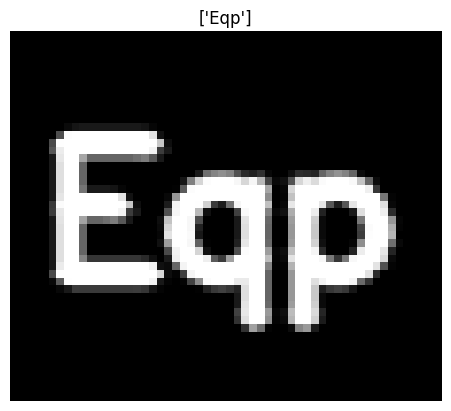

In [3]:
import matplotlib.pyplot as plt

plt.imshow(first_img)
plt.title(first_ann['/metadata/text'])
plt.axis('off')
plt.show()


<a name ="training"></a>

## 🏋️‍♂️ Training


<a name ="configuration"></a>

### ⚙️ Configuration


We'll start from `configs/ocr_recognition_light_model.yaml` and adjust only the dataset name to our synthetic dataset and a few training hyperparameters to keep the run short.


In [ ]:
%%writefile synthetic_ocr_config.yaml
model:
  name: synthetic_ocr_model
  predefined_model:
    name: OCRRecognitionModel
    variant: light
    params:
      alphabet: alphanumeric
      max_text_len: 40
      ignore_unknown: true

loader:
  params:
    dataset_name: synthetic_ocr_dataset

trainer:
  preprocessing:
    train_image_size: [48, 320]
    keep_aspect_ratio: true
    normalize:
      active: true

  batch_size: 8
  epochs: 100
  n_workers: 4
  validation_interval: 2
  n_log_images: 4

  optimizer:
    name: Adam
    params:
      lr: 0.001

  scheduler:
    name: ConstantLR


<a name ="train"></a>

### 🦾 Train


To start the training, we need to initialize the `LuxonisModel`, pass it the path to the configuration file, and call the `train()` method on it.

**Note**: LuxonisTrain also supports all these commands through usage of its CLI ([docs here](https://github.com/luxonis/luxonis-train/tree/main?tab=readme-ov-file#-cli)), no code required. We won't use them for tutorial purposes, but feel free to use them when you do it yourself.

In [ ]:
from luxonis_train import LuxonisModel

config_path = "synthetic_ocr_config.yaml"

ocr_model = LuxonisModel(config_path)
ocr_model.train()


`LuxonisTrain` has also already implemented automatic tracking of training runs. By default, `Tensorboard` is used, and to look at the losses, metrics, and visualizations during training, we can inspect the logs. If you check the `output` folder, you'll see that every run creates a new directory, and each run also has its training logs in the `./output/tensorboard_logs` where the name of the folder matches the run's name. To make all the subsequent commands work automatically, please set the name of your run below.

In [ ]:
RUN_NAME = "<YOUR_RUN_NAME>"

In [ ]:
%load_ext tensorboard
%tensorboard --logdir output/tensorboard_logs/{RUN_NAME}/ # TODO: Change the name of the training run

<a name ="test"></a>

## ✍ Test


Now, we have a trained model that performs well on the validation set. The next step is to check its performance on the testing set, a collection of images we've kept hidden from the model. It should only be used to evaluate whether the model is good objectively. Since this is an image classification task, we use the Accuracy, Recall, and F1 Score metrics to check the model performance quantitatively.

If you check out the run directory, you'll see two folders inside: `best_val_metric` and `min_val_loss`. Both have checkpoint files generated during training based on best validation metric performance and minimal validation loss. For evaluation, we'll want to use one of these checkpoints; we recommend that you use one that has the lowest validation loss.

In [ ]:
weights = ocr_model.get_min_loss_checkpoint_path()
# weights = ocr_model.get_best_metric_checkpoint_path() # gets checkpoint where validation metric was the highest
metrics = ocr_model.test(view="test", weights=weights)

WARNING  Key `losses.OCRCTCHead.CTCLoss._node.fc.weight` was not found in checkpoint.      ]8;id=64635;file:///home/paperspace/.local/lib/python3.10/site-packages/luxonis_train/lightning/luxonis_lightning.py\luxonis_lightning.py]8;;\:]8;id=799304;file:///home/paperspace/.local/lib/python3.10/site-packages/luxonis_train/lightning/luxonis_lightning.py#619\619]8;;\

WARNING  Key `losses.OCRCTCHead.CTCLoss._node.fc.bias` was not found in checkpoint.        ]8;id=59025;file:///home/paperspace/.local/lib/python3.10/site-packages/luxonis_train/lightning/luxonis_lightning.py\luxonis_lightning.py]8;;\:]8;id=858708;file:///home/paperspace/.local/lib/python3.10/site-packages/luxonis_train/lightning/luxonis_lightning.py#619\619]8;;\

WARNING  Key `metrics.OCRCTCHead.OCRAccuracy._node.fc.weight` was not found in checkpoint. ]8;id=758213;file:///home/paperspace/.local/lib/python3.10/site-packages/luxonis_train/lightning/luxonis_lightning.py\luxonis_lightning.py]8;;\:]8;id=827519;file:///home/paperspace/.local/lib/python3.10/site-packages/luxonis_train/lightning/luxonis_lightning.py#619\619]8;;\

WARNING  Key `metrics.OCRCTCHead.OCRAccuracy._node.fc.bias` was not found in checkpoint.   ]8;id=718697;file:///home/paperspace/.local/lib/python3.10/site-packages/luxonis_train/lightning/luxonis_lightning.py\luxonis_lightning.py]8;;\:]8;id=126715;file:///home/paperspace/.local/lib/python3.10/site-packages/luxonis_train/lightning/luxonis_lightning.py#619\619]8;;\

WARNING  Key `visualizers.OCRCTCHead.OCRVisualizer._node.fc.weight` was not found in       ]8;id=100896;file:///home/paperspace/.local/lib/python3.10/site-packages/luxonis_train/lightning/luxonis_lightning.py\luxonis_lightning.py]8;;\:]8;id=429985;file:///home/paperspace/.local/lib/python3.10/site-packages/luxonis_train/lightning/luxonis_lightning.py#619\619]8;;\
         checkpoint.                                                                                               

...

Metrics:

       OCRCTCHead        
┏━━━━━━━━━━━━━┳━━━━━━━━━┓
┃ Name        ┃ Value   ┃
┡━━━━━━━━━━━━━╇━━━━━━━━━┩
│ OCRAccuracy │ 0.91000 │
│ rank_0      │ 0.91000 │
│ rank_1      │ 0.06000 │
│ rank_2      │ 0.00000 │
└─────────────┴─────────┘

───────────────────────────────────────────────────────────────────────────────────────────────────────────────────

INFO     Test main metric (OCRCTCHead/OCRAccuracy): 0.9100                                 ]8;id=584914;file:///home/paperspace/.local/lib/python3.10/site-packages/luxonis_train/lightning/luxonis_lightning.py\luxonis_lightning.py]8;;\:]8;id=774681;file:///home/paperspace/.local/lib/python3.10/site-packages/luxonis_train/lightning/luxonis_lightning.py#803\803]8;;\

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃            Test metric             ┃            DataLoader 0            ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│             test/loss              │         0.285217821598053          │
│    test/loss/OCRCTCHead/CTCLoss    │         0.285217821598053          │
│ test/metric/OCRCTCHead/OCRAccuracy │         0.9100000262260437         │
│   test/metric/OCRCTCHead/rank_0    │         0.9100000262260437         │
│   test/metric/OCRCTCHead/rank_1    │        0.05999999865889549         │
│   test/metric/OCRCTCHead/rank_2    │                0.0                 │
└────────────────────────────────────┴────────────────────────────────────┘

<a name ="infer"></a>

### 🧠 Infer


Usually, we also want to visualize the prediction of the trained model on test images to ensure it does what it is supposed to do. This is called inference, and we can perform it either on one of the views (e.g., test) or a random image, directory of images, or whole video (for more details, refer to the [docs](https://github.com/luxonis/luxonis-train/tree/main?tab=readme-ov-file#inference)). In our case, we'll infer the model on test images.

In [ ]:
# NOTE: If you are using Google Colab use this and images will be saved to "infer_results_ocr" directory
ocr_model.infer(weights=weights, save_dir="infer_results_ocr", view="test")

# NOTE: If you are not using Google Colab use this and images will be displayed
# ocr_model.infer(
#     weights=weights,
#     view="test"
# ) 

Now, let's visualize one of the predictions.

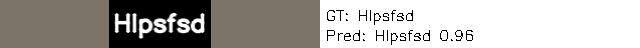

In [10]:
from IPython.display import Image
Image(filename='infer_results_ocr/OCRCTCHead_OCRVisualizer_0.png')

<a name ="export-and-archive"></a>

## 🗂️ Export and Archive


Once the model is trained and tested, we want to prepare it for deployment on the device. This preparation consists of 2 steps. First, we want to export the model trained with PyTorch to a more general format called [`Open Neural Network Exchange (ONNX)`](https://onnx.ai/). Then, we want to package this exported model with all the metadata containing information about the inputs, outputs, and training configuration used. This is called archiving. These steps can be done quickly with just one command in `LuxonisTrain`.

In [ ]:
archive_path = ocr_model.archive(weights=weights)
NN_ARCHIVE_PATH = archive_path
print("Model archived to:", archive_path)

Notice that two new folders were created in our run directory. One is called `export` and has an ONNX model while the other is called `archive` which has `.tar.xz` file. The tar file is a compressed file that holds the aforementioned ONNX model with all the model metadata.

<a name ="deploy"></a>

## 🤖 Deploy


Now that we have successfully exported and archived the model, we aim to deploy it to the Luxonis device. The model's specific format depends on the Luxonis device series you have. We will show you how to use our [`HubAI SDK`](https://github.com/luxonis/hubai-sdk) to convert the model as simply as possible.

We'll start by installing the `HubAI SDK`.

In [ ]:
%pip install -q hubai-sdk

We will use the `HubAI SDK` Python API, which leverages our [`HubAI`](https://hub.luxonis.com) platform to perform model conversion in the background. To get started, you'll need to create an account on `HubAI` and obtain your team’s API key.

In [ ]:
HUBAI_API_KEY = "<YOUR_HUBAI_API_KEY>"

Model conversion can be done via either the CLI or the Python API — here, we'll use the latter. For more information, see the [HubAI SDK documentation](https://github.com/luxonis/hubai-sdk).

The call below creates a new model card within your team on `HubAI`, uploads the model file and metadata, then performs cloud-side conversion to the selected target platform (e.g., [`RVC2`](https://rvc4.docs.luxonis.com/hardware/platform/rvc/rvc2/), [`RVC4`](https://rvc4.docs.luxonis.com/hardware/platform/rvc/rvc4/)). Once completed, the converted model is automatically downloaded to your device.

For HubAI-specific conversion parameters, refer to the [parameter documentation](https://github.com/luxonis/hubai-sdk/blob/main/docs/available_parameters.md#model-parameters). Platform-specific parameters are also documented there.


In [ ]:
from hubai_sdk import HubAIClient

client = HubAIClient(api_key=HUBAI_API_KEY)

response = client.convert.RVC2(
    path=NN_ARCHIVE_PATH,
    name="OCR Recognition Model",
    description_short="Synthetic OCR recognizer",
    tasks=["OPTICAL_CHARACTER_RECOGNITION"],
    license_type="MIT",
    is_public=False,
)

converted_model_path = response.downloaded_path

We have successfully converted our trained model for an RVC2 device, so let's test it! Please copy the path to the downloaded archive with the converted model from the output log of the last code cell; we will use it in the next section.

In [5]:
MODEL_PATH = "<YOUR_DOWNLOADED_MODEL_ARCHIVE_PATH>"

<a name ="depthai-script"></a>

## 📷 DepthAI Script

To run the model on a DepthAI device you can use the [General OCR example](https://github.com/luxonis/oak-examples/tree/main/neural-networks/ocr/general-ocr) from the [luxonis/oak-examples](https://github.com/luxonis/oak-examples) repository. This example demonstrates how to set up the DepthAI pipeline for OCR tasks and can be adapted to use your custom-trained model.

To use your model, you need to modify the `main.py` script by inserting your model's slug and API key.

``` python
rec_model_description.model = "MODEL_SLUG_HERE"
rec_model_nn_archive = dai.NNArchive(dai.getModelFromZoo(rec_model_description, apiKey="API_KEY_HERE"))
```

You can find the model slug by sleecting your model variant on HubAI and clicking on the "Copy" button.

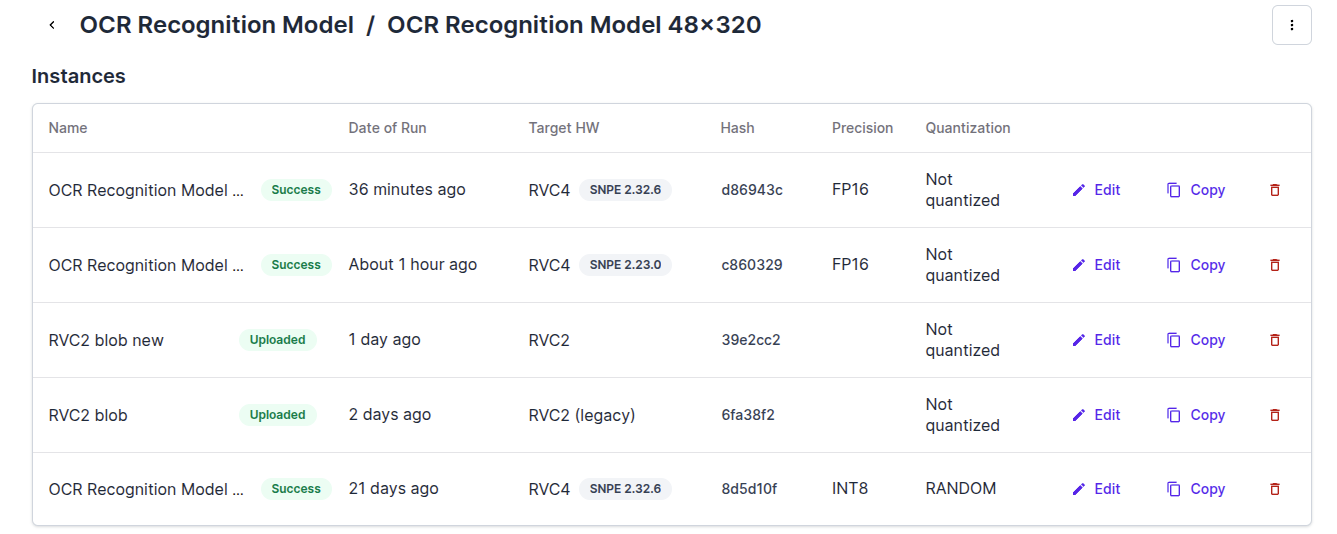

Yay! 🎉🎉🎉 Huge congratulations, you have successfully finished this tutorial in which you deployed an OCR model model trained using `luxonis-train` on a dataset to our camera!